<a href="https://colab.research.google.com/github/Demi-Khaled/Deep-Learning/blob/main/Brain_MRI_SVM_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain MRI Tumor Classification

**Two-approach pipeline + Glioma recall fix:**
1. **Approach 2** – End-to-end ResNet50 fine-tuning with **Focal Loss** (trained first)
2. **Approach 1** – Fine-tuned ResNet50 features → SVM with boosted glioma class weight
3. **Glioma threshold tuning** – Post-hoc inference fix (no retraining needed)
4. **Full comparison** across all variants


## 0. Setup: Mount Drive & Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path     = "/content/drive/MyDrive/BrainMRI.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")


Done extracting!


In [4]:
train_dir = "/content/dataset/Training"
test_dir  = "/content/dataset/Testing"


## 1. Data Generators

Two sets of generators are defined:
- **Augmented** (`train_data`, `val_data`, `test_data`) — for DL training (Approach 2)
- **Non-augmented** (`train_data_noaug`) — for SVM feature extraction (Approach 1),
  `shuffle=False` so features stay aligned with labels


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE   = 224
BATCH_SIZE = 32

# Augmented generators — used for Approach 2 DL training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # MUST be False for evaluation alignment
)

# Non-augmented train generator — used for Approach 1 SVM feature extraction
noaug_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # MUST be False so features align with labels
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Found 5600 images belonging to 4 classes.


## 2. Focal Loss Definition

**Why focal loss?** Standard cross-entropy treats all samples equally.
Focal loss down-weights easy, well-classified examples and focuses training
on hard, ambiguous cases — exactly the glioma/meningioma boundary.

- `gamma=2.0` — how aggressively to down-weight easy samples
- `alpha=0.25` — global scaling factor

> This replaces `categorical_crossentropy` in `model.compile()` for Approach 2.


In [6]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal loss for multi-class classification.
    Focuses training on hard examples (e.g. glioma/meningioma confusion).
    gamma : down-weighting exponent for easy samples (2.0 is standard)
    alpha : overall loss scaling factor
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = alpha * tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal_weight * ce)
    return loss_fn

print("Focal loss defined — will be used in Approach 2 model.compile()")


Focal loss defined — will be used in Approach 2 model.compile()


## 3. Class Weights

We define **two** sets of class weights:
- `class_weights_balanced` — auto-computed from label frequency (used in Approach 2 as a sanity check)
- `class_weights_glioma` — manually boosted glioma weight ×2 (used in Approach 1 SVM training)

> Boosting glioma's weight tells the model that missing a glioma is twice as costly
> as missing any other class, directly pushing recall up.


In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = train_data.classes

# Auto-balanced weights (printed for reference)
balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_balanced = dict(enumerate(balanced_weights))
print("Balanced class weights:", class_weights_balanced)

# Glioma-boosted weights for Approach 1 SVM
# class index order: 0=glioma, 1=meningioma, 2=notumor, 3=pituitary
# (verify with test_data.class_indices if unsure)
class_weights_glioma = {
    0: 2.0,   # glioma — penalise misses harder to boost recall
    1: 1.0,   # meningioma
    2: 1.0,   # notumor
    3: 1.0    # pituitary
}
print("Glioma-boosted class weights:", class_weights_glioma)
print("\nClass index mapping:", test_data.class_indices)


Balanced class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}
Glioma-boosted class weights: {0: 2.0, 1: 1.0, 2: 1.0, 3: 1.0}

Class index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


---
## Approach 2 (End-to-End): ResNet50 + Focal Loss

> Trained first because Approach 1 reuses the fine-tuned backbone as a feature extractor.

**Changes vs baseline:**
- `categorical_crossentropy` → **`focal_loss(gamma=2.0)`** to target glioma/meningioma confusion
- `ReduceLROnPlateau patience=4` < `EarlyStopping patience=8` so LR reduction can fire first


### 2.1 Build Model & Phase 1 Training (frozen backbone)

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Phase 1: Freeze entire backbone — train only the custom head
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = BatchNormalization()(x)
x      = Dense(512, activation='relu')(x)
x      = Dropout(0.5)(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ── GLIOMA FIX 1: Use focal loss instead of categorical_crossentropy ──────
# Focal loss focuses the model on hard, ambiguous samples (glioma/meningioma)
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

phase1_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=phase1_callbacks
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.4954 - loss: 0.0595
Epoch 1: val_accuracy improved from None to 0.83661, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 103s 612ms/step - accuracy: 0.6158 - loss: 0.0412 - val_accuracy: 0.8366 - val_loss: 0.0120
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7382 - loss: 0.0247
Epoch 2: val_accuracy improved from 0.83661 to 0.87589, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 563ms/step - accuracy: 0.7482 - loss: 0.0233 - val_accuracy: 0.8759 - val_loss: 0.0087
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7776 - loss: 0.0194
Epoch 3: val_accuracy did not improve from 0.87589
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 565ms/step - accuracy: 0.7864 - loss: 0.0185 - val_accuracy: 0.8598 - val_los

### 2.2 Phase 2 Training (fine-tune top ResNet50 layers)

In [9]:
# Unfreeze the last 60 layers of ResNet50 for fine-tuning
for layer in base_model.layers[-60:]:
    layer.trainable = True

# ── GLIOMA FIX 1 (continued): Keep focal loss for Phase 2 as well ─────────
model.compile(
    optimizer=Adam(1e-5),   # Much lower LR for fine-tuning
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# ReduceLROnPlateau patience (4) < EarlyStopping patience (8)
# so LR reduction fires before early stopping kicks in
phase2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, verbose=1),
    ModelCheckpoint('best_phase2.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=phase2_callbacks
)


Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8364 - loss: 0.0114
Epoch 1: val_loss improved from None to 0.00556, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 120s 640ms/step - accuracy: 0.8386 - loss: 0.0111 - val_accuracy: 0.9134 - val_loss: 0.0056 - learning_rate: 1.0000e-05
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8822 - loss: 0.0080
Epoch 2: val_loss improved from 0.00556 to 0.00513, saving model to best_phase2.keras

Epoch 2: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 618ms/step - accuracy: 0.8801 - loss: 0.0081 - val_accuracy: 0.9116 - val_loss: 0.0051 - learning_rate: 1.0000e-05
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8896 - loss: 0.0073
Epoch 3: val_loss improved from 0.00513 to 0.00468, saving model to best_phase2.keras

Epoch 3: finished saving model to best_phase2.keras
140/140 ━━━━━━━━━━━━━━━━━

### 2.3 Evaluate Approach 2 (DL with Focal Loss)

In [10]:
from sklearn.metrics import classification_report, accuracy_score

# Always reset before predicting to ensure prediction order matches generator.classes
test_data.reset()

preds_dl  = model.predict(test_data)
y_pred_dl = np.argmax(preds_dl, axis=1)
y_true    = test_data.classes

dl_acc = accuracy_score(y_true, y_pred_dl)
print("Approach 2 - DL Accuracy (Focal Loss):", dl_acc)
print(classification_report(
    y_true, y_pred_dl,
    target_names=list(test_data.class_indices.keys())
))


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step
Approach 2 - DL Accuracy (Focal Loss): 0.931875
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.87      0.94      0.90       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



---
## Approach 1: Fine-tuned ResNet50 Features → SVM

We extract features from the **GlobalAveragePooling2D** layer of the trained
model and pass them to an SVM. The SVM uses **glioma-boosted class weights**
(`glioma: 2.0`) to push glioma recall higher.


### 3.1 Build Feature Extractor

In [11]:
from tensorflow.keras.models import Model as KerasModel

# Extract from the GAP layer of the TRAINED model (not a new random layer)
gap_layer         = model.get_layer('global_average_pooling2d')
feature_extractor = KerasModel(inputs=model.input, outputs=gap_layer.output)

print("Feature extractor output shape:", feature_extractor.output_shape)


Feature extractor output shape: (None, 2048)


### 3.2 Extract Features

In [12]:
def extract_features(generator, extractor):
    """Iterate all batches of a generator and collect deep features."""
    features, labels = [], []
    for i in range(len(generator)):
        x, y = generator[i]
        f = extractor.predict(x, verbose=0)
        features.append(f)
        labels.append(y)
    return np.vstack(features), np.vstack(labels)

test_data.reset()  # Start from beginning before extracting test features

X_train_raw, y_train_raw = extract_features(train_data_noaug, feature_extractor)
X_test_raw,  y_test_raw  = extract_features(test_data,        feature_extractor)

# Convert one-hot to integer class indices
y_train = np.argmax(y_train_raw, axis=1)
y_test  = np.argmax(y_test_raw,  axis=1)

print("Train features shape:", X_train_raw.shape)
print("Test  features shape:", X_test_raw.shape)


Train features shape: (5600, 2048)
Test  features shape: (1600, 2048)


### 3.3 Scale Features & Train SVM with Glioma-Boosted Weights

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Fit scaler on train only — transform test without re-fitting
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ── GLIOMA FIX 2: Boosted glioma class weight in SVM ─────────────────────
# class_weight='balanced' treats all classes equally.
# We override glioma (index 0) to weight=2.0 so the SVM is penalised
# twice as much for missing a glioma — directly boosting glioma recall.
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight=class_weights_glioma,  # {0:2.0, 1:1.0, 2:1.0, 3:1.0}
    probability=True   # needed for threshold tuning in Section 5
)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)


### 3.4 Evaluate Approach 1 (SVM with Glioma Boost)

In [14]:
svm_acc = accuracy_score(y_test, y_pred_svm)
print("Approach 1 - SVM Accuracy (Glioma Boost):", svm_acc)
print(classification_report(
    y_test, y_pred_svm,
    target_names=list(test_data.class_indices.keys())
))


Approach 1 - SVM Accuracy (Glioma Boost): 0.94375
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.88       400
  meningioma       0.87      0.99      0.93       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



---
## 4. Glioma Threshold Tuning (No Retraining Needed)

**Idea:** By default the model picks `argmax(probabilities)`, which is
equivalent to a threshold of 0.25 per class (1/4 for 4 classes).
We lower the glioma threshold so the model calls "glioma" even when
it's only moderately confident — trading a little precision for higher recall.

This is applied to **both** the DL model and the SVM independently.

> In clinical settings, missing a glioma (false negative) is far more dangerous
> than a false positive, so this trade-off is well justified.


In [15]:
# ── GLIOMA FIX 3: Lower decision threshold for glioma ────────────────────
# Class indices: verify with test_data.class_indices
print("Class indices:", test_data.class_indices)
GLIOMA_IDX = list(test_data.class_indices.keys()).index('glioma')
print(f"Glioma class index: {GLIOMA_IDX}")


Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Glioma class index: 0


### 4.1 Threshold Tuning on DL Model

In [16]:
# Sweep a range of thresholds and evaluate glioma recall + overall accuracy
from sklearn.metrics import recall_score

thresholds  = np.arange(0.10, 0.45, 0.05)
results_dl  = []

test_data.reset()
preds_dl = model.predict(test_data)   # raw softmax probabilities

for thresh in thresholds:
    y_pred_thresh = np.argmax(preds_dl, axis=1).copy()
    # Override: if glioma probability >= threshold, classify as glioma
    y_pred_thresh[preds_dl[:, GLIOMA_IDX] >= thresh] = GLIOMA_IDX
    acc_t    = accuracy_score(y_true, y_pred_thresh)
    recall_t = recall_score(y_true, y_pred_thresh, labels=[GLIOMA_IDX], average='macro')
    results_dl.append((thresh, acc_t, recall_t))
    print(f"  threshold={thresh:.2f}  accuracy={acc_t:.4f}  glioma_recall={recall_t:.4f}")

# Pick the threshold that maximises glioma recall while keeping accuracy >= 0.93
best_dl = max(
    [r for r in results_dl if r[1] >= 0.93],
    key=lambda r: r[2]
)
BEST_THRESH_DL = best_dl[0]
print(f"\n>> Best DL threshold: {BEST_THRESH_DL:.2f}  "
      f"(accuracy={best_dl[1]:.4f}, glioma_recall={best_dl[2]:.4f})")


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step
  threshold=0.10  accuracy=0.8919  glioma_recall=0.8750
  threshold=0.15  accuracy=0.9031  glioma_recall=0.8475
  threshold=0.20  accuracy=0.9137  glioma_recall=0.8475
  threshold=0.25  accuracy=0.9200  glioma_recall=0.8450
  threshold=0.30  accuracy=0.9250  glioma_recall=0.8300
  threshold=0.35  accuracy=0.9244  glioma_recall=0.8125
  threshold=0.40  accuracy=0.9300  glioma_recall=0.8075

>> Best DL threshold: 0.40  (accuracy=0.9300, glioma_recall=0.8075)


### 4.2 Final DL Evaluation at Best Threshold

In [17]:
y_pred_dl_tuned = np.argmax(preds_dl, axis=1).copy()
y_pred_dl_tuned[preds_dl[:, GLIOMA_IDX] >= BEST_THRESH_DL] = GLIOMA_IDX

dl_tuned_acc = accuracy_score(y_true, y_pred_dl_tuned)
print(f"Approach 2 DL (threshold={BEST_THRESH_DL:.2f}) Accuracy: {dl_tuned_acc:.4f}")
print(classification_report(
    y_true, y_pred_dl_tuned,
    target_names=list(test_data.class_indices.keys())
))


Approach 2 DL (threshold=0.40) Accuracy: 0.9300
              precision    recall  f1-score   support

      glioma       0.96      0.81      0.88       400
  meningioma       0.88      0.92      0.90       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



### 4.3 Threshold Tuning on SVM

In [18]:
# SVM was trained with probability=True so predict_proba is available
svm_probs   = svm.predict_proba(X_test_scaled)
results_svm = []

for thresh in thresholds:
    y_pred_thresh = np.argmax(svm_probs, axis=1).copy()
    y_pred_thresh[svm_probs[:, GLIOMA_IDX] >= thresh] = GLIOMA_IDX
    acc_t    = accuracy_score(y_test, y_pred_thresh)
    recall_t = recall_score(y_test, y_pred_thresh, labels=[GLIOMA_IDX], average='macro')
    results_svm.append((thresh, acc_t, recall_t))
    print(f"  threshold={thresh:.2f}  accuracy={acc_t:.4f}  glioma_recall={recall_t:.4f}")

best_svm = max(
    [r for r in results_svm if r[1] >= 0.93],
    key=lambda r: r[2]
)
BEST_THRESH_SVM = best_svm[0]
print(f"\n>> Best SVM threshold: {BEST_THRESH_SVM:.2f}  "
      f"(accuracy={best_svm[1]:.4f}, glioma_recall={best_svm[2]:.4f})")


  threshold=0.10  accuracy=0.9475  glioma_recall=0.8425
  threshold=0.15  accuracy=0.9487  glioma_recall=0.8350
  threshold=0.20  accuracy=0.9469  glioma_recall=0.8200
  threshold=0.25  accuracy=0.9475  glioma_recall=0.8200
  threshold=0.30  accuracy=0.9487  glioma_recall=0.8200
  threshold=0.35  accuracy=0.9481  glioma_recall=0.8175
  threshold=0.40  accuracy=0.9456  glioma_recall=0.8075

>> Best SVM threshold: 0.10  (accuracy=0.9475, glioma_recall=0.8425)


### 4.4 Final SVM Evaluation at Best Threshold

In [20]:
y_pred_svm_tuned = np.argmax(svm_probs, axis=1).copy()
y_pred_svm_tuned[svm_probs[:, GLIOMA_IDX] >= BEST_THRESH_SVM] = GLIOMA_IDX

svm_tuned_acc = accuracy_score(y_test, y_pred_svm_tuned)
print(f"Approach 1 SVM (threshold={BEST_THRESH_SVM:.2f}) Accuracy: {svm_tuned_acc:.4f}")
print(classification_report(
    y_test, y_pred_svm_tuned,
    target_names=list(test_data.class_indices.keys())
))


Approach 1 SVM (threshold=0.10) Accuracy: 0.9475
              precision    recall  f1-score   support

      glioma       0.96      0.84      0.90       400
  meningioma       0.90      0.96      0.93       400
     notumor       0.94      1.00      0.97       400
   pituitary       1.00      0.98      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



---
## 5. Full Comparison: All Variants

Summary chart comparing:
- Approach 2 DL (baseline argmax)
- Approach 2 DL (tuned glioma threshold)
- Approach 1 SVM (glioma class weight boost)
- Approach 1 SVM (tuned glioma threshold)


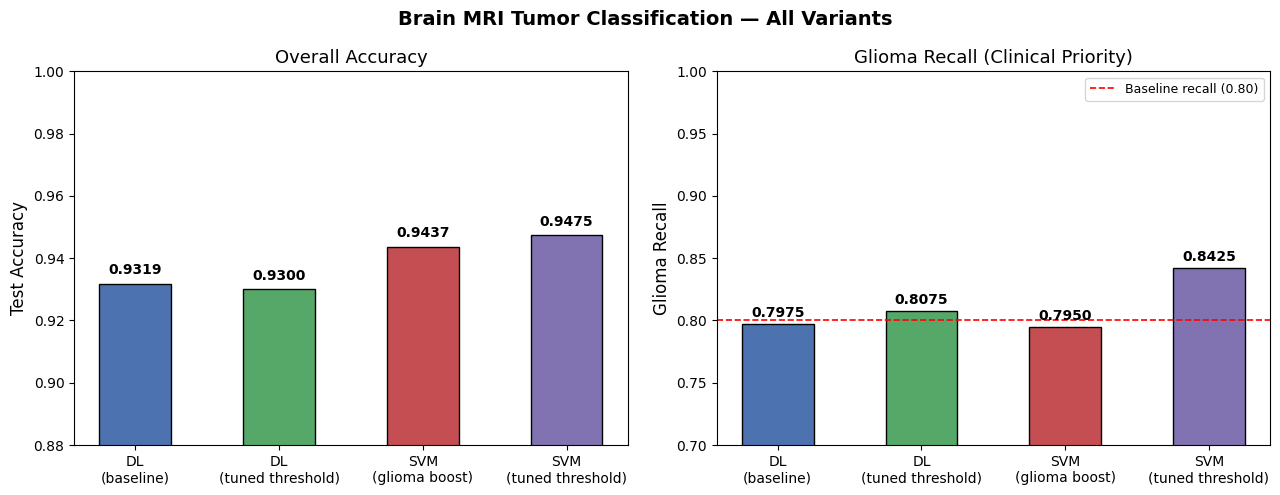


=== SUMMARY ===
DL (baseline)                   accuracy=0.9319  glioma_recall=0.7975
DL (tuned threshold)            accuracy=0.9300  glioma_recall=0.8075
SVM (glioma boost)              accuracy=0.9437  glioma_recall=0.7950
SVM (tuned threshold)           accuracy=0.9475  glioma_recall=0.8425


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

labels_plot = [
    'DL\n(baseline)',
    'DL\n(tuned threshold)',
    'SVM\n(glioma boost)',
    'SVM\n(tuned threshold)'
]

accuracies = [
    dl_acc,
    dl_tuned_acc,
    svm_acc,
    svm_tuned_acc
]

glioma_recalls = [
    recall_score(y_true, y_pred_dl,        labels=[GLIOMA_IDX], average='macro'),
    recall_score(y_true, y_pred_dl_tuned,  labels=[GLIOMA_IDX], average='macro'),
    recall_score(y_test, y_pred_svm,       labels=[GLIOMA_IDX], average='macro'),
    recall_score(y_test, y_pred_svm_tuned, labels=[GLIOMA_IDX], average='macro')
]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Overall Accuracy ──────────────────────────────────────────────────────
bars1 = ax1.bar(labels_plot, accuracies, color=colors, width=0.5, edgecolor='black')
ax1.set_ylim(0.88, 1.0)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Overall Accuracy', fontsize=13)
for bar, v in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Glioma Recall ─────────────────────────────────────────────────────────
bars2 = ax2.bar(labels_plot, glioma_recalls, color=colors, width=0.5, edgecolor='black')
ax2.set_ylim(0.70, 1.0)
ax2.set_ylabel('Glioma Recall', fontsize=12)
ax2.set_title('Glioma Recall (Clinical Priority)', fontsize=13)
ax2.axhline(y=0.80, color='red', linestyle='--', linewidth=1.2, label='Baseline recall (0.80)')
ax2.legend(fontsize=9)
for bar, v in zip(bars2, glioma_recalls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Brain MRI Tumor Classification — All Variants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150)
plt.show()

print("\n=== SUMMARY ===")
for name, acc, rec in zip(labels_plot, accuracies, glioma_recalls):
    print(f"{name.replace(chr(10),' '):30s}  accuracy={acc:.4f}  glioma_recall={rec:.4f}")
